BFGS Test Accuracy: 0.9908940397350994
Newton-CG Test Accuracy: 0.9908940397350994
SDG Test Accuracy: 0.9271523178807947


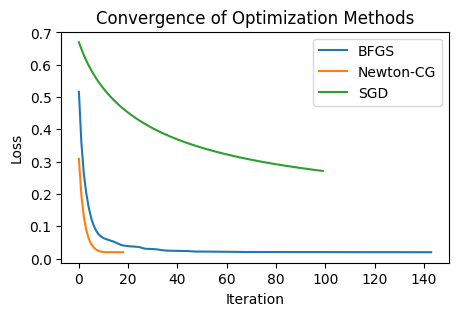

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --------------------------------------------------
# Load and prepare data
# --------------------------------------------------
high = pd.read_csv("high_popularity_spotify_data.csv")
low = pd.read_csv("low_popularity_spotify_data.csv")

high = high.dropna()
low = low.dropna()

high["label"] = 1
low["label"] = 0

data = pd.concat([high, low], axis=0).reset_index(drop=True)

# Keep only numeric features
X = data.select_dtypes(include=[np.number]).drop(columns=["label"])
y = data["label"].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Add bias term
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

# --------------------------------------------------
# Logistic regression loss, gradient, Hessian
# --------------------------------------------------
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def loss(w, X, y):
    z = X @ w
    return np.mean(np.log(1 + np.exp(z)) - y * z)

def grad(w, X, y):
    z = X @ w
    return X.T @ (sigmoid(z) - y) / len(y)

def hess(w, X, y):
    z = X @ w
    s = sigmoid(z)
    R = s * (1 - s)
    return X.T @ (X * R[:, None]) / len(y)

# Initial weights
w0 = np.zeros(X_train.shape[1])

# --------------------------------------------------
# Track convergence
# --------------------------------------------------
loss_bfgs = []
loss_newton = []
loss_SGD = []

def callback_bfgs(w):
    loss_bfgs.append(loss(w, X_train, y_train))

def callback_newton(w):
    loss_newton.append(loss(w, X_train, y_train))

# --------------------------------------------------
# Optimization
# --------------------------------------------------
res_bfgs = minimize(
    loss,
    w0,
    args=(X_train, y_train),
    jac=grad,
    method="BFGS",
    callback=callback_bfgs
)

res_newton = minimize(
    loss,
    w0,
    args=(X_train, y_train),
    jac=grad,
    hess=hess,
    method="Newton-CG",
    callback=callback_newton
)

w_sgd = np.zeros(X_train.shape[1])
lr = 0.1
epochs = 100
for i in range(epochs):
    gradient = grad(w_sgd, X_train, y_train)
    w_sgd -= lr * gradient
    loss_SGD.append(loss(w_sgd, X_train, y_train))

# --------------------------------------------------
# Evaluation
# --------------------------------------------------
y_pred_bfgs = (sigmoid(X_test @ res_bfgs.x) >= 0.5).astype(int)
y_pred_newton = (sigmoid(X_test @ res_newton.x) >= 0.5).astype(int)
y_pred_SDG = (sigmoid(X_test @ w_sgd) >= 0.5).astype(int)

print("BFGS Test Accuracy:", accuracy_score(y_test, y_pred_bfgs))
print("Newton-CG Test Accuracy:", accuracy_score(y_test, y_pred_newton))
print("SDG Test Accuracy:", accuracy_score(y_test, y_pred_SDG))

# --------------------------------------------------
# Convergence plots
# --------------------------------------------------
plt.figure(figsize = (5, 3))
plt.plot(loss_bfgs, label='BFGS')
plt.plot(loss_newton, label='Newton-CG')
plt.plot(loss_SGD, label='SGD')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Convergence of Optimization Methods")
plt.legend()
plt.show()